In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

In [3]:
X = X.astype("float32") / 255.0
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (56000, 784)
X_test shape: (14000, 784)


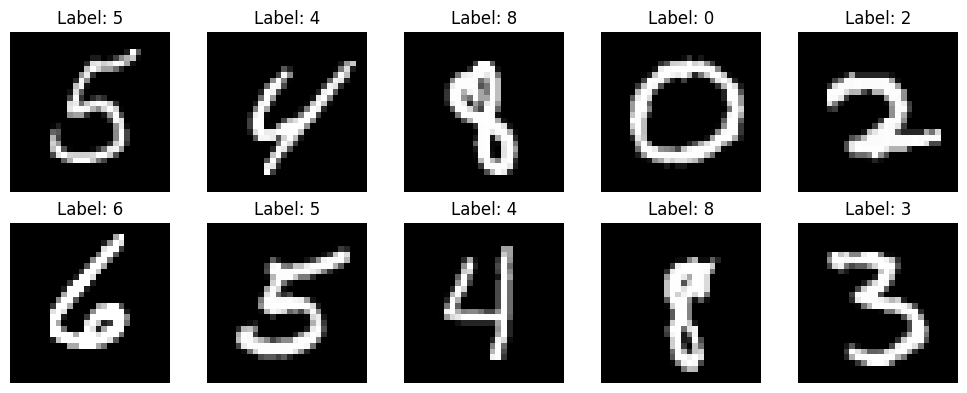

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
input_dim = 784
latent_dim = 64

input_layer = Input(shape=(input_dim,))

encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

encoder = Model(inputs=input_layer, outputs=latent)

In [35]:
autoencoder.compile(
    optimizer=Adam(),
    loss='mse'
)

autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,512 (884.81 KB)

 Trainable params: 226,512 (884.81 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0615 - val_loss: 0.0342
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0286 - val_loss: 0.0244
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0217 - val_loss: 0.0200
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0190 - val_loss: 0.0179
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0171 - val_loss: 0.0162
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0156 - val_loss: 0.0152
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0145 - val_loss: 0.0140
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0137 - val_loss: 0.0134
Epoch 9/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0130 - val_loss: 0.0130
Epoch 10/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0124 - val_loss: 0.0121


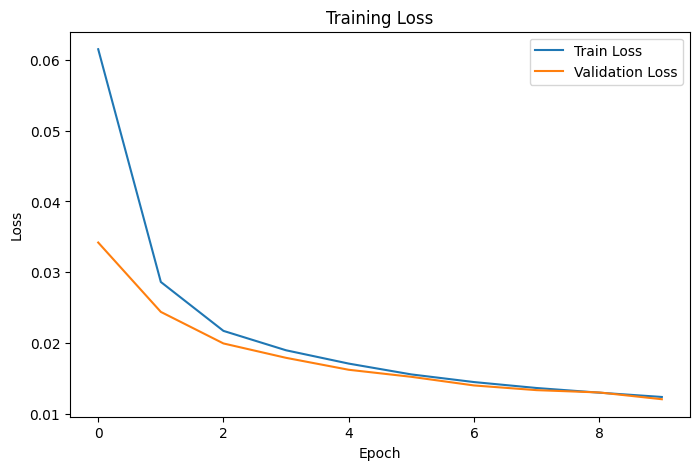

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

In [23]:
reconstructed = autoencoder.predict(X_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


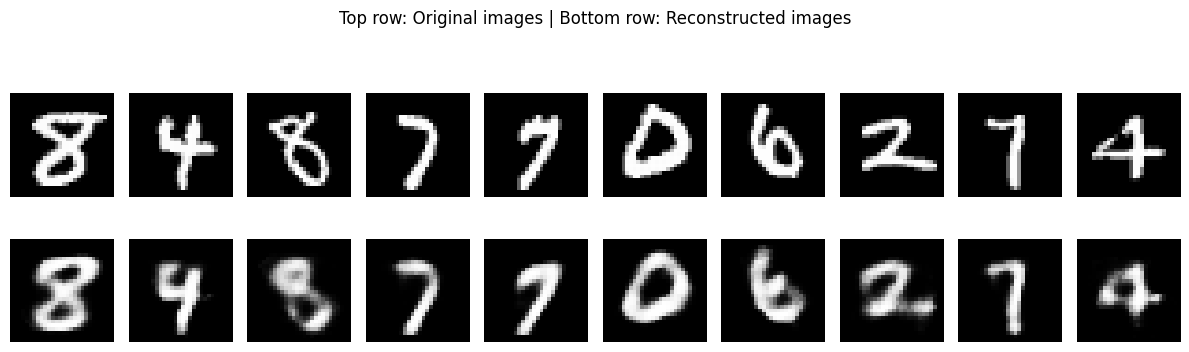

In [38]:
plt.figure(figsize=(12, 4))

for i in range(10):

    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.suptitle("Top row: Original images | Bottom row: Reconstructed images")
plt.tight_layout()
plt.show()

In [39]:
X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded train shape: (56000, 64)
Encoded test shape: (14000, 64)


In [40]:
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_encoded)

In [43]:
query_index = 0
query_image = X_test[query_index].reshape(1, -1)

query_encoded = encoder.predict(query_image)

similarities = cosine_similarity(query_encoded, X_train_encoded)[0]

top_k = 10
top_indices = np.argsort(similarities)[-top_k:][::-1]

print("Top 5 similar image indices:", top_indices)
print("Similarity scores:", similarities[top_indices])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Top 5 similar image indices: [51601 14235 45916 21735  1423 34914 30435 34802 27075  4821]
Similarity scores: [0.9967479  0.9931259  0.9913191  0.9908265  0.9903275  0.98947704
 0.9894729  0.989328   0.9889643  0.9887625 ]


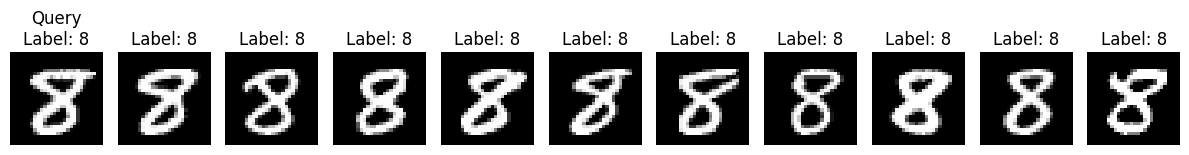

In [44]:
plt.figure(figsize=(12, 3))

plt.subplot(1, top_k + 1, 1)
plt.imshow(query_image.reshape(28, 28), cmap='gray')
plt.title(f"Query\nLabel: {y_test[query_index]}")
plt.axis('off')

for i, idx in enumerate(top_indices):
    plt.subplot(1, top_k + 1, i + 2)
    plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()